# GNN Routing - Graph Attention Network for Traffic-Aware Routing
### PyTorch Geometric: https://pytorch-geometric.readthedocs.io
### Data prepared by: data_prep.ipynb

**Overview:**
Trains a Graph Attention Network (GAT) on the road graph and congestion time series produced by `data_prep.ipynb`. The GAT learns to predict a congestion score for each road segment (edge) given the current traffic state at neighboring zones (nodes). These predicted scores are used as edge weights in Dijkstra's algorithm to recommend the least-congested route between any two zones.

**Why GAT:**
A GAT propagates information across the graph - the predicted congestion on one road segment is informed by traffic conditions on neighboring segments. This captures the spatial dependency structure of traffic described in the literature: congestion at one node influences adjacent nodes.

**Baseline comparison:**
GNN-predicted routing is compared against uniform-weight Dijkstra (treats all roads as equally congested) to demonstrate the value of learned congestion prediction.

---
## Cell 1 - Environment Setup

In [16]:
# import dependencies
import sys
import os
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import subprocess
import numpy as np
import networkx as nx
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from IPython.display import display as ipy_display, Image as IPyImage

# checks that dependencies are available
print(f"Python           : {sys.version}")
print(f"PyTorch          : {torch.__version__}")
print(f"CUDA             : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    subprocess.run(['bash', '-c', 'module load cuda/11.8.0'], shell=False)

import torch_geometric
print(f"PyG              : {torch_geometric.__version__}")

# File paths
BASE_DIR    = os.path.expanduser('~/AdvAI_Final')
DATA_PATH   = os.path.join(BASE_DIR, 'routing', 'data_prep_output.pt')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'routing', 'predictions')
MODELS_DIR  = os.path.join(BASE_DIR, 'detection', 'models')
WEBSITE_DIR = os.path.join(BASE_DIR, 'website', 'results')
GNN_CKPT    = os.path.join(MODELS_DIR, 'gnn_routing.pt')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WEBSITE_DIR, exist_ok=True)

# Training hyperparameters
HIDDEN_DIM   = 128
NUM_LAYERS   = 4
GAT_HEADS    = 4
EPOCHS       = 2500
LR           = 0.001
TRAIN_SPLIT  = 0.8   # fraction of timesteps used for training
WINDOW_SIZE  = 10    # number of past timesteps the model sees to predict next timestep
                     # mimics real-time routing — only use recent congestion history

print(f"\nBase         : {BASE_DIR}")
print(f"Data path    : {DATA_PATH}")
print(f"GNN checkpoint: {GNN_CKPT}")
print(f"Device       : {device}")
print(f"\nHyperparameters:")
print(f"  Hidden dim  : {HIDDEN_DIM}")
print(f"  GAT layers  : {NUM_LAYERS}")
print(f"  Heads       : {GAT_HEADS}")
print(f"  Epochs      : {EPOCHS}")
print(f"  Window size : {WINDOW_SIZE} timesteps")

Python           : 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
PyTorch          : 2.7.1+cu118
CUDA             : True
GPU              : Tesla V100S-PCIE-32GB
PyG              : 2.7.0

Base         : /users/PGS0295/atrautzs/AdvAI_Final
Data path    : /users/PGS0295/atrautzs/AdvAI_Final/routing/data_prep_output.pt
GNN checkpoint: /users/PGS0295/atrautzs/AdvAI_Final/detection/models/gnn_routing.pt
Device       : cuda

Hyperparameters:
  Hidden dim  : 128
  GAT layers  : 4
  Heads       : 4
  Epochs      : 2500
  Window size : 10 timesteps


---
## Cell 2 - Load Dataset

Loads `data_prep_output.pt` and verifies the interface contract - shapes and dtypes must match what the GAT expects.

In [17]:
if not os.path.exists(DATA_PATH):
    print(f"Dataset not found: {DATA_PATH}")
    print("Run data_prep.ipynb first to generate this file.")
else:
    data_dict = torch.load(DATA_PATH, map_location=device)

    edge_index    = data_dict['edge_index'].to(device)
    node_coords   = data_dict['node_coords'].to(device)
    congestion    = data_dict['congestion'].to(device)     # [num_nodes, num_timesteps]
    num_nodes     = data_dict['num_nodes']
    num_timesteps = data_dict['num_timesteps']
    sequence_ids  = data_dict['sequence_ids']
    seq_node_map  = data_dict['seq_node_map']

    print("Dataset loaded successfully.")
    print()
    print(f"  edge_index    : {edge_index.shape}  dtype={edge_index.dtype}")
    print(f"  node_coords   : {node_coords.shape}  dtype={node_coords.dtype}")
    print(f"  congestion    : {congestion.shape}  dtype={congestion.dtype}")
    print(f"  num_nodes     : {num_nodes}")
    print(f"  num_timesteps : {num_timesteps}")
    print(f"  sequences     : {sequence_ids}")
    print()
    print(f"  Congestion range : [{congestion.min():.4f}, {congestion.max():.4f}]")
    print(f"  Mean congestion  : {congestion.mean():.4f}")

    # Build sliding window training pairs
    # Instead of predicting the mean of held-out timesteps from all training timesteps,
    # we slide a window of size WINDOW_SIZE across the full time series.
    # Each window gives: x = congestion[:, t:t+WINDOW_SIZE], y = congestion[:, t+WINDOW_SIZE]
    # This forces the model to predict the NEXT timestep from recent history -
    # directly mimicking real-time routing where only recent congestion is available.
    windows_x = []  # list of [num_nodes, WINDOW_SIZE] tensors
    windows_y = []  # list of [num_nodes] tensors

    for t in range(num_timesteps - WINDOW_SIZE):
        x = congestion[:, t : t + WINDOW_SIZE]          # [num_nodes, WINDOW_SIZE]
        y = congestion[:, t + WINDOW_SIZE]               # [num_nodes]
        windows_x.append(x)
        windows_y.append(y)

    windows_x = torch.stack(windows_x)  # [num_windows, num_nodes, WINDOW_SIZE]
    windows_y = torch.stack(windows_y)  # [num_windows, num_nodes]

    # Split windows into train and val
    split_w    = int(len(windows_x) * 0.8)
    train_x    = windows_x[:split_w]    # [train_windows, num_nodes, WINDOW_SIZE]
    train_y    = windows_y[:split_w]    # [train_windows, num_nodes]
    val_x      = windows_x[split_w:]
    val_y      = windows_y[split_w:]

    print(f"  Window size      : {WINDOW_SIZE} timesteps")
    print(f"  Total windows    : {len(windows_x)}")
    print(f"  Train windows    : {len(train_x)}")
    print(f"  Val windows      : {len(val_x)}")
    print()
    print(f"  Model input shape per forward pass: [{num_nodes}, {WINDOW_SIZE}]")
    print(f"  Model output shape per forward pass: [{num_nodes}]")

Dataset loaded successfully.

  edge_index    : torch.Size([2, 4780])  dtype=torch.int64
  node_coords   : torch.Size([1260, 2])  dtype=torch.float32
  congestion    : torch.Size([1260, 100])  dtype=torch.float32
  num_nodes     : 1260
  num_timesteps : 100
  sequences     : ['uav0000013_00000_v', 'uav0000013_01073_v', 'uav0000013_01392_v', 'uav0000020_00406_v', 'uav0000071_03240_v', 'uav0000072_04488_v', 'uav0000072_05448_v', 'uav0000072_06432_v', 'uav0000076_00720_v', 'uav0000079_00480_v', 'uav0000084_00000_v', 'uav0000086_00000_v', 'uav0000099_02109_v', 'uav0000117_02622_v', 'uav0000124_00944_v', 'uav0000126_00001_v', 'uav0000137_00458_v', 'uav0000138_00000_v', 'uav0000140_01590_v', 'uav0000143_02250_v', 'uav0000145_00000_v', 'uav0000150_02310_v', 'uav0000182_00000_v', 'uav0000218_00001_v', 'uav0000222_03150_v', 'uav0000239_03720_v', 'uav0000239_12336_v', 'uav0000243_00001_v', 'uav0000244_01440_v', 'uav0000248_00001_v', 'uav0000263_03289_v', 'uav0000264_02760_v', 'uav0000266_03598_v

---
## Cell 3 - Define GCN Model

A three-layer Graph Convolutional Network. Each GCNConv layer aggregates features from neighboring nodes, allowing each zone to incorporate the congestion state of adjacent zones. The output is a single congestion score per node - used as edge weight for routing.

**Input features per node:** congestion time series (num_timesteps values)

**Output per node:** predicted congestion score (scalar)

The model is trained to predict the next timestep's congestion from the current state - a one-step forecasting objective that forces it to learn the spatial propagation patterns of congestion across the graph.

In [18]:
from torch_geometric.nn import GATConv

class TrafficGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_layers, heads=4):
        super().__init__()
        self.convs     = nn.ModuleList()
        self.bns       = nn.ModuleList()
        self.residuals = nn.ModuleList()

        # Input projection - projects window of timesteps to hidden dim
        self.input_proj = nn.Linear(in_dim, hidden_dim)

        # Input layer
        self.convs.append(GATConv(hidden_dim, hidden_dim, heads=heads, concat=False, dropout=0.2))
        self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.residuals.append(nn.Identity())

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_dim, hidden_dim, heads=heads, concat=False, dropout=0.2))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
            self.residuals.append(nn.Identity())

        # Output layer
        self.out_conv = GATConv(hidden_dim, hidden_dim // 2, heads=1, concat=False, dropout=0.1)
        self.out_fc   = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x, edge_index):
        # x: [num_nodes, WINDOW_SIZE]
        x = F.relu(self.input_proj(x))

        for conv, bn, res in zip(self.convs, self.bns, self.residuals):
            x_in = x
            x    = conv(x, edge_index)
            x    = bn(x)
            x    = F.elu(x)
            x    = F.dropout(x, p=0.2, training=self.training)
            x    = x + res(x_in)

        x = self.out_conv(x, edge_index)
        x = F.elu(x)
        x = self.out_fc(x)
        return torch.sigmoid(x).squeeze(-1)  # [num_nodes] in [0, 1]


# Input dim is now WINDOW_SIZE not num_timesteps
in_dim = WINDOW_SIZE
model  = TrafficGAT(in_dim, HIDDEN_DIM, NUM_LAYERS, heads=GAT_HEADS).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"TrafficGAT architecture:")
print(f"  Input dim    : {in_dim} (window of {WINDOW_SIZE} recent timesteps)")
print(f"  Hidden dim   : {HIDDEN_DIM}")
print(f"  GAT layers   : {NUM_LAYERS}")
print(f"  Heads        : {GAT_HEADS}")
print(f"  Output       : predicted congestion at next timestep per node")
print(f"  Total params : {total_params:,}")
print()
print(model)

TrafficGAT architecture:
  Input dim    : 10 (window of 10 recent timesteps)
  Hidden dim   : 128
  GAT layers   : 4
  Heads        : 4
  Output       : predicted congestion at next timestep per node
  Total params : 210,689

TrafficGAT(
  (convs): ModuleList(
    (0-2): 3 x GATConv(128, 128, heads=4)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (residuals): ModuleList(
    (0-2): 3 x Identity()
  )
  (input_proj): Linear(in_features=10, out_features=128, bias=True)
  (out_conv): GATConv(128, 64, heads=1)
  (out_fc): Linear(in_features=64, out_features=1, bias=True)
)


---
## Cell 4A - Train GCN - 2500 Epochs

Trains TrafficGCN to predict each node's congestion at the next timestep given its neighborhood's current state. Loss is MSE between predicted and actual congestion. Training and validation loss are tracked per epoch.

Starting TrafficGAT training — temporal window approach
  Epochs       : 2500
  Loss         : MSE
  Window size  : 10 timesteps → predict next timestep
  Train windows: 72
  Val windows  : 18
  Optimizer    : Adam (lr=0.001 → cosine warm restarts → 1e-5)
  Nodes        : 1260
  Edges        : 4780

  Epoch     1/2500   train: 0.022888   val: 0.013602   best: 0.013602   lr: 0.001000
  Epoch   100/2500   train: 0.009319   val: 0.008113   best: 0.008084   lr: 0.000905
  Epoch   200/2500   train: 0.008790   val: 0.007749   best: 0.007749   lr: 0.000658
  Epoch   300/2500   train: 0.008439   val: 0.007762   best: 0.007692   lr: 0.000352
  Epoch   400/2500   train: 0.008242   val: 0.007700   best: 0.007647   lr: 0.000105
  Epoch   500/2500   train: 0.008230   val: 0.007673   best: 0.007647   lr: 0.001000
  Epoch   600/2500   train: 0.008325   val: 0.007802   best: 0.007647   lr: 0.000976
  Epoch   700/2500   train: 0.006283   val: 0.005867   best: 0.005815   lr: 0.000905
  Epoch   800/2500 

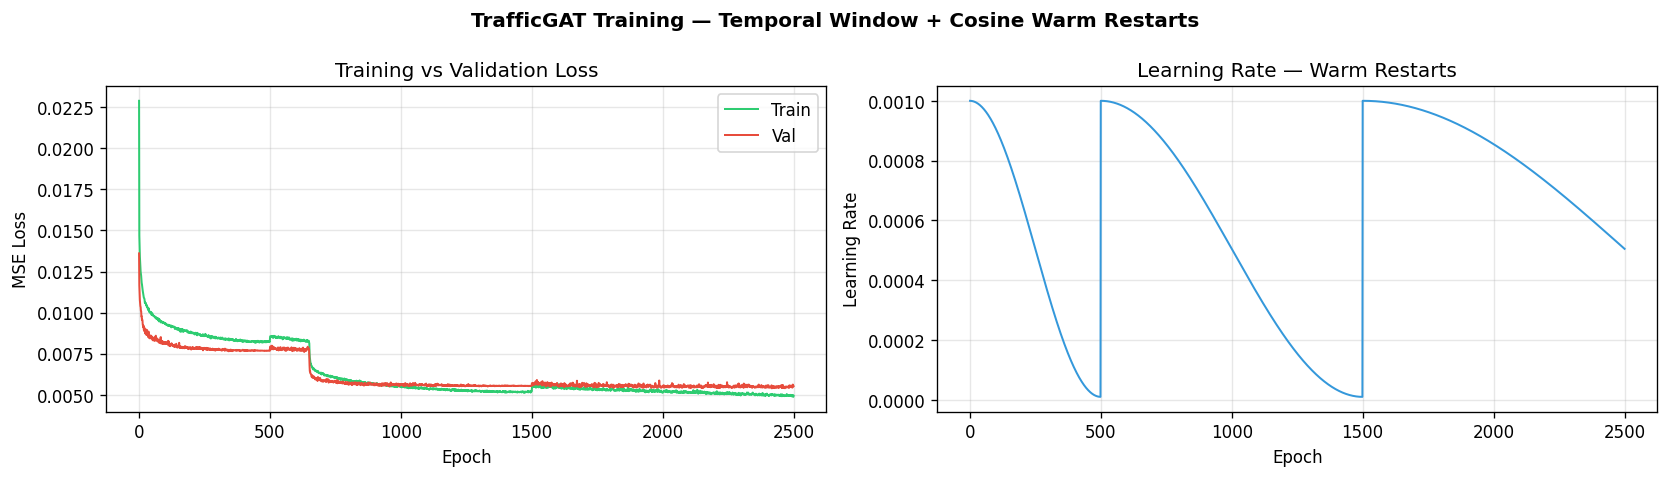

In [19]:
optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
criterion  = nn.MSELoss()
scheduler  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=500, T_mult=2, eta_min=1e-5
)

train_losses = []
val_losses   = []
lr_history   = []
best_loss    = float('inf')

print(f"Starting TrafficGAT training — temporal window approach")
print(f"  Epochs       : {EPOCHS}")
print(f"  Loss         : MSE")
print(f"  Window size  : {WINDOW_SIZE} timesteps → predict next timestep")
print(f"  Train windows: {len(train_x)}")
print(f"  Val windows  : {len(val_x)}")
print(f"  Optimizer    : Adam (lr={LR} → cosine warm restarts → 1e-5)")
print(f"  Nodes        : {num_nodes}")
print(f"  Edges        : {edge_index.shape[1]}")
print()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    perm = torch.randperm(len(train_x))

    for idx in perm:
        x_win = train_x[idx]   # [num_nodes, WINDOW_SIZE]
        y_win = train_y[idx]   # [num_nodes]
        optimizer.zero_grad()
        noise = torch.randn_like(x_win) * 0.05
        pred  = model(x_win + noise, edge_index)
        loss  = criterion(pred, y_win)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_train_loss = epoch_loss / len(train_x)
    train_losses.append(avg_train_loss)
    lr_history.append(optimizer.param_groups[0]['lr'])

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for idx in range(len(val_x)):
            pred     = model(val_x[idx], edge_index)
            val_loss += criterion(pred, val_y[idx]).item()
        avg_val_loss = val_loss / len(val_x)
        val_losses.append(avg_val_loss)

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), GNN_CKPT)

    if epoch % 100 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>5}/{EPOCHS}   train: {avg_train_loss:.6f}   val: {avg_val_loss:.6f}   best: {best_loss:.6f}   lr: {optimizer.param_groups[0]['lr']:.6f}")

print()
print(f"Training complete.")
print(f"Best val loss  : {best_loss:.6f}")
print(f"Checkpoint     : {GNN_CKPT}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('TrafficGAT Training — Temporal Window + Cosine Warm Restarts',
             fontsize=12, fontweight='bold')

axes[0].plot(range(1, EPOCHS + 1), train_losses, color='#2ecc71', linewidth=1.2, label='Train')
axes[0].plot(range(1, EPOCHS + 1), val_losses,   color='#e74c3c', linewidth=1.2, label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), lr_history, color='#3498db', linewidth=1.2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate — Warm Restarts')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
loss_path = os.path.join(OUTPUT_DIR, 'gnn_training_loss.png')
plt.savefig(loss_path, dpi=120, bbox_inches='tight')
plt.close()
shutil.copy(loss_path, os.path.join(WEBSITE_DIR, 'gnn_training_loss.png'))
ipy_display(IPyImage(filename=loss_path))

---
## Cell 4B - Train GCN - Custom Epochs

In [58]:
epochs_input  = input("Enter number of epochs for custom run (e.g. 500, 1000): ").strip()
EPOCHS_CUSTOM = int(epochs_input)

model_custom  = TrafficGAT(in_dim, HIDDEN_DIM, NUM_LAYERS, heads=GAT_HEADS).to(device)
opt_custom    = torch.optim.Adam(model_custom.parameters(), lr=LR)
sched_custom  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt_custom, T_0=min(500, EPOCHS_CUSTOM // 3), T_mult=2, eta_min=1e-5
)
criterion_c   = nn.MSELoss()
losses_custom = []
best_custom   = float('inf')
ckpt_custom   = os.path.join(MODELS_DIR, f'gnn_routing_{EPOCHS_CUSTOM}epoch.pt')

print(f"Starting custom TrafficGAT run — {EPOCHS_CUSTOM} epochs")
print()

model_custom.train()
for epoch in range(1, EPOCHS_CUSTOM + 1):
    opt_custom.zero_grad()
    noise = torch.randn_like(graph_data.x) * 0.05
    pred  = model_custom(graph_data.x + noise, edge_index)
    loss  = criterion_c(pred, graph_data.y)
    loss.backward()
    opt_custom.step()
    sched_custom.step()
    losses_custom.append(loss.item())

    if loss.item() < best_custom:
        best_custom = loss.item()
        torch.save(model_custom.state_dict(), ckpt_custom)

    if epoch % max(1, EPOCHS_CUSTOM // 10) == 0 or epoch == 1:
        print(f"  Epoch {epoch:>5}/{EPOCHS_CUSTOM}   loss: {loss.item():.6f}   best: {best_custom:.6f}   lr: {opt_custom.param_groups[0]['lr']:.6f}")

print()
print(f"Custom training complete. Best loss: {best_custom:.6f}")
print(f"Checkpoint: {ckpt_custom}")

Enter number of epochs for custom run (e.g. 500, 1000):  10


Starting custom TrafficGAT run — 10 epochs
  Window size  : 10 timesteps → predict next timestep
  Train windows: 72

  Epoch     1/10   loss: 0.027772   best: 0.027772   lr: 0.000753
  Epoch     2/10   loss: 0.015415   best: 0.015415   lr: 0.000258
  Epoch     3/10   loss: 0.014675   best: 0.014675   lr: 0.001000
  Epoch     4/10   loss: 0.014214   best: 0.014214   lr: 0.000934
  Epoch     5/10   loss: 0.013586   best: 0.013586   lr: 0.000753
  Epoch     6/10   loss: 0.013171   best: 0.013171   lr: 0.000505
  Epoch     7/10   loss: 0.012832   best: 0.012832   lr: 0.000258
  Epoch     8/10   loss: 0.012678   best: 0.012678   lr: 0.000076
  Epoch     9/10   loss: 0.012534   best: 0.012534   lr: 0.001000
  Epoch    10/10   loss: 0.012591   best: 0.012534   lr: 0.000983

Custom training complete. Best loss: 0.012534
Checkpoint: /users/PGS0295/atrautzs/AdvAI_Final/detection/models/gnn_routing_10epoch.pt


---
## Cell 5 - Evaluate - GNN vs Baseline

Loads the best checkpoint and compares two routing strategies across all node pairs:

- **Baseline** - Dijkstra with uniform edge weights (all roads treated equally)
- **GNN** - Dijkstra with GAT-predicted congestion scores as edge weights

The metric is average route congestion: the mean predicted congestion score along the recommended path. Lower is better - a good router avoids high-congestion edges.

GNN predicted congestion scores per node (from last 10 timesteps):
  Node    0: 0.0074
  Node    1: 0.0067
  Node    2: 0.0096
  Node    3: 0.3763
  Node    4: 0.2015
  Node    5: 0.0036
  Node    6: 0.0095
  Node    7: 0.0049
  Node    8: 0.0083
  Node    9: 0.0065
  Node   10: 0.0085
  Node   11: 0.0067
  Node   12: 0.0078
  Node   13: 0.0331
  Node   14: 0.0049
  Node   15: 0.2771
  Node   16: 0.0067
  Node   17: 0.0082
  Node   18: 0.0120
  Node   19: 0.0118
  Node   20: 0.0039
  Node   21: 0.4937
  Node   22: 0.0035
  Node   23: 0.3467
  Node   24: 0.0038
  Node   25: 0.0037
  Node   26: 0.0037
  Node   27: 0.4184
  Node   28: 0.0038
  Node   29: 0.0035
  Node   30: 0.0034
  Node   31: 0.4795
  Node   32: 0.0038
  Node   33: 0.0067
  Node   34: 0.0043
  Node   35: 0.0033
  Node   36: 0.0038
  Node   37: 0.0039
  Node   38: 0.0067
  Node   39: 0.0175
  Node   40: 0.0117
  Node   41: 0.0005
  Node   42: 0.0044
  Node   43: 0.0144
  Node   44: 0.0032
  Node   45: 0.0043
  Node   46: 

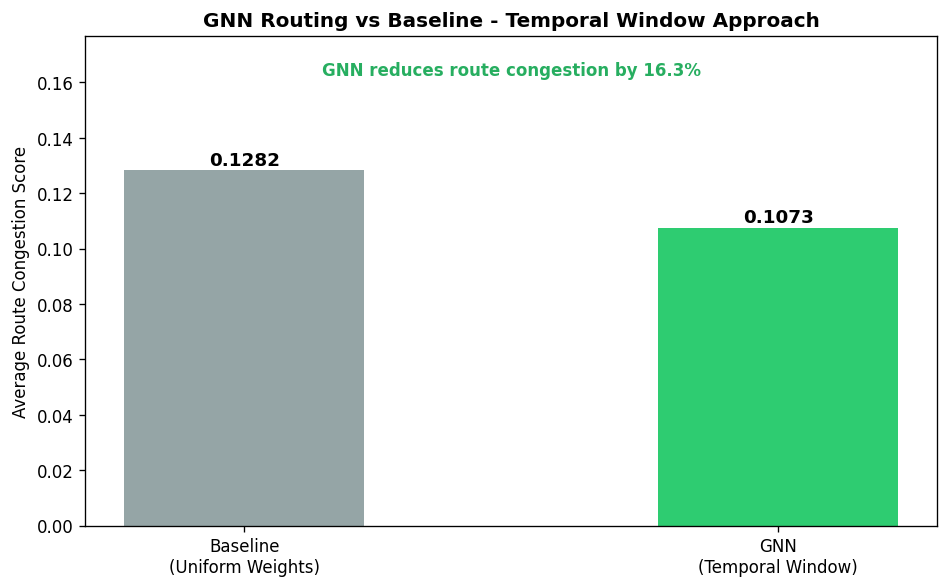

In [20]:
# Load best checkpoint
model.load_state_dict(torch.load(GNN_CKPT, map_location=device))
model.eval()

# At inference time use the last WINDOW_SIZE timesteps as the current window
# This mimics real deployment - you only have access to recent congestion history
with torch.no_grad():
    current_window = congestion[:, -WINDOW_SIZE:]    # [num_nodes, WINDOW_SIZE]
    gnn_scores     = model(current_window, edge_index).cpu().numpy()  # [num_nodes]

print(f"GNN predicted congestion scores per node (from last {WINDOW_SIZE} timesteps):")
for i, s in enumerate(gnn_scores):
    print(f"  Node {i:>4}: {s:.4f}")
print()

# Build NetworkX graphs for routing
G_baseline = nx.DiGraph()
G_gnn      = nx.DiGraph()

src_list = edge_index[0].cpu().tolist()
dst_list = edge_index[1].cpu().tolist()

for s, d in zip(src_list, dst_list):
    G_baseline.add_edge(s, d, weight=1.0)
    gnn_w = float((gnn_scores[s] + gnn_scores[d]) / 2)
    G_gnn.add_edge(s, d, weight=max(gnn_w, 1e-6))

# Evaluate over all valid source-destination pairs
nodes          = list(range(num_nodes))
baseline_congs = []
gnn_congs      = []
pair_results   = []

for src in nodes:
    for dst in nodes:
        if src == dst:
            continue
        try:
            path_base = nx.shortest_path(G_baseline, src, dst, weight='weight')
            path_gnn  = nx.shortest_path(G_gnn,      src, dst, weight='weight')
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            continue

        cong_base = float(np.mean([gnn_scores[n] for n in path_base]))
        cong_gnn  = float(np.mean([gnn_scores[n] for n in path_gnn]))
        baseline_congs.append(cong_base)
        gnn_congs.append(cong_gnn)
        pair_results.append((src, dst, path_base, path_gnn, cong_base, cong_gnn))

avg_base = float(np.mean(baseline_congs)) if baseline_congs else 0
avg_gnn  = float(np.mean(gnn_congs))      if gnn_congs      else 0
improv   = ((avg_base - avg_gnn) / avg_base * 100) if avg_base > 0 else 0

divergent    = [(b, g) for _, _, pb, pg, b, g in pair_results if pb != pg]
div_base_avg = float(np.mean([b for b, g in divergent])) if divergent else 0
div_gnn_avg  = float(np.mean([g for b, g in divergent])) if divergent else 0
div_improv   = ((div_base_avg - div_gnn_avg) / div_base_avg * 100) if div_base_avg > 0 else 0

print("=" * 55)
print(f"{'Strategy':<30} {'Avg Route Congestion':>20}")
print("-" * 55)
print(f"{'Baseline (uniform weights)':<30} {avg_base:>20.4f}")
print(f"{'GNN (learned weights)':<30} {avg_gnn:>20.4f}")
print("-" * 55)
print(f"Overall improvement    : {improv:.1f}%")
print(f"Pairs evaluated        : {len(pair_results)}")
print()
print(f"--- Divergent routes only (GNN chose differently) ---")
print(f"Divergent pairs        : {len(divergent)} / {len(pair_results)}")
if divergent:
    print(f"Baseline avg cong      : {div_base_avg:.4f}")
    print(f"GNN avg cong           : {div_gnn_avg:.4f}")
    print(f"Improvement on these   : {div_improv:.1f}%")
print("=" * 55)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ['Baseline\n(Uniform Weights)', 'GNN\n(Temporal Window)'],
    [avg_base, avg_gnn],
    color=['#95a5a6', '#2ecc71'],
    width=0.45
)
ax.set_ylabel('Average Route Congestion Score')
ax.set_title('GNN Routing vs Baseline - Temporal Window Approach',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(avg_base, avg_gnn) * 1.3 + 0.01)
for bar, val in zip(bars, [avg_base, avg_gnn]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.text(0.5, 0.92, f'GNN reduces route congestion by {improv:.1f}%',
        transform=ax.transAxes, ha='center', fontsize=10,
        color='#27ae60', fontweight='bold')
plt.tight_layout()
eval_path = os.path.join(OUTPUT_DIR, 'gnn_vs_baseline.png')
plt.savefig(eval_path, dpi=120, bbox_inches='tight')
plt.close()
shutil.copy(eval_path, os.path.join(WEBSITE_DIR, 'gnn_vs_baseline.png'))
ipy_display(IPyImage(filename=eval_path))

---
## Cell 6 - Interactive - Route Recommendation

Select a sequence, then pick source and destination zones within that scene. The GNN predicts congestion scores and Dijkstra finds the optimal route. Both baseline and GNN paths are displayed overlaid on the actual aerial image from that sequence.

Available sequences (only sequences with edges can be routed):

Seq ID                          Zones  Edges   Min Cong   Max Cong   Spread
----------------------------------------------------------------------------
  uav0000013_00000_v               20     38     0.0072     0.3783   0.3711
  uav0000013_01073_v               20     37     0.0042     0.4822   0.4781
  uav0000013_01392_v               20     38     0.0004     0.2857   0.2853
  uav0000020_00406_v               20     38     0.0005     0.4075   0.4071
  uav0000071_03240_v               20     37     0.0090     0.2392   0.2301
  uav0000072_04488_v               20     38     0.0065     0.5012   0.4947
  uav0000072_05448_v               20     35     0.0134     0.4227   0.4092
  uav0000072_06432_v               20     38     0.0021     0.6143   0.6122
  uav0000076_00720_v               20     38     0.0119     0.7704   0.7586
  uav0000079_00480_v               20     41     0.0003     0.1553   0.1550
  uav0000084_00000_v   

Enter sequence ID from the list above:  uav0000326_01035_v               



Sequence uav0000326_01035_v — 20 zones:
  Color thresholds: Low < 0.2237 | Medium 0.2237–0.2679 | High > 0.2679

   Local Zone  Global Node  Raw Score   Relative  Level
  --------------------------------------------------------
            0         1060     0.2708     0.7350  HIGH
            1         1061     0.2563     0.6847  MEDIUM
            2         1062     0.2235     0.5707  LOW
            3         1063     0.3471     1.0000  HIGH
            4         1064     0.2339     0.6066  MEDIUM
            5         1065     0.3165     0.8937  HIGH
            6         1066     0.2437     0.6408  MEDIUM
            7         1067     0.2646     0.7133  MEDIUM
            8         1068     0.1274     0.2366  LOW
            9         1069     0.2948     0.8185  HIGH
           10         1070     0.0938     0.1198  LOW
           11         1071     0.2385     0.6226  MEDIUM
           12         1072     0.3409     0.9786  HIGH
           13         1073     0.0748     0.0536 

Enter source zone (0 to 19):  10
Enter destination zone (0 to 19):  12



Route: Zone 10 → Zone 12
  Baseline path : 10 → 16 → 12
  Baseline cong : 0.2460
  GNN path      : 10 → 16 → 12
  GNN cong      : 0.2460
  Note: Both methods chose the same route for this pair


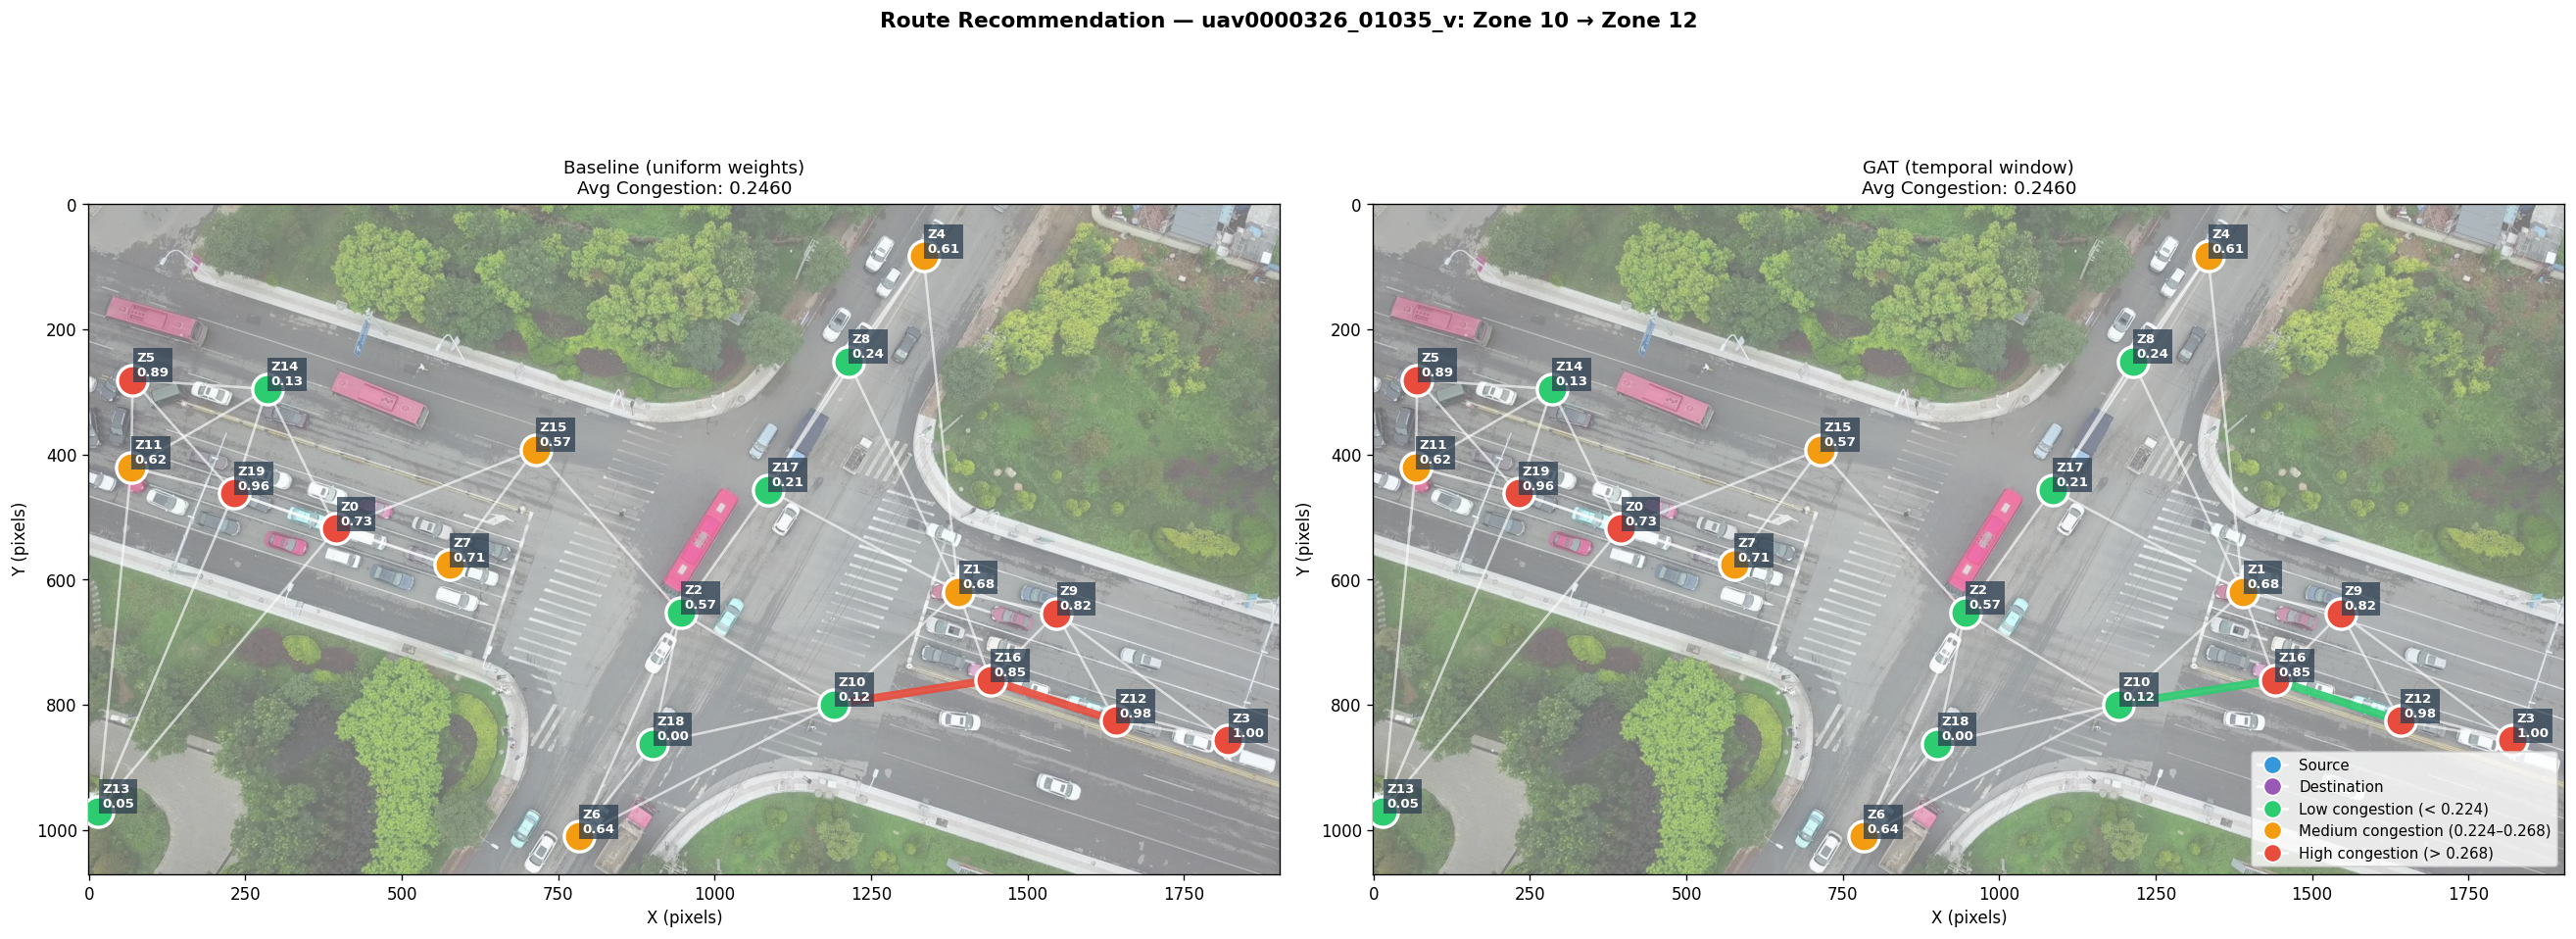


Saved: /users/PGS0295/atrautzs/AdvAI_Final/routing/predictions/route_uav0000326_01035_v_z10_to_z12.png


In [77]:
from matplotlib.lines import Line2D
import matplotlib.image as mpimg

# Load best checkpoint
model.load_state_dict(torch.load(GNN_CKPT, map_location=device))

# Get GNN scores using last WINDOW_SIZE timesteps
model.eval()
with torch.no_grad():
    current_window = congestion[:, -WINDOW_SIZE:]
    scores = model(current_window, edge_index).cpu().numpy()

coords = node_coords.cpu().numpy()

# Step 1 — show available sequences
print("Available sequences (only sequences with edges can be routed):")
print()
print(f"{'Seq ID':<30} {'Zones':>6} {'Edges':>6} {'Min Cong':>10} {'Max Cong':>10} {'Spread':>8}")
print("-" * 76)

routable = {}
for seq_id, local_nodes in seq_node_map.items():
    s_set   = set(local_nodes)
    n_edges = sum(
        1 for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist())
        if s in s_set and d in s_set
    ) // 2
    if n_edges == 0:
        continue
    seq_scores = scores[local_nodes]
    routable[seq_id] = local_nodes
    spread = float(seq_scores.max() - seq_scores.min())
    print(f"  {str(seq_id):<28} {len(local_nodes):>6} {n_edges:>6} "
          f"{seq_scores.min():>10.4f} {seq_scores.max():>10.4f} {spread:>8.4f}")

print()
print(f"{len(routable)} sequences available for routing.")
print()

# Step 2 — pick a sequence
seq_choice = input("Enter sequence ID from the list above: ").strip()

if seq_choice not in routable:
    print(f"Sequence '{seq_choice}' not found or has no edges.")
else:
    local_nodes = routable[seq_choice]
    n_local     = len(local_nodes)
    seq_scores  = scores[local_nodes]
    seq_coords  = coords[local_nodes]

    # Compute sequence-relative percentile thresholds for coloring
    # This makes colors meaningful even when absolute values are similar
    p33 = float(np.percentile(seq_scores, 33))
    p66 = float(np.percentile(seq_scores, 66))

    # Show zone summary with relative ranking
    print()
    print(f"Sequence {seq_choice} — {n_local} zones:")
    print(f"  Color thresholds: Low < {p33:.4f} | Medium {p33:.4f}–{p66:.4f} | High > {p66:.4f}")
    print()
    print(f"  {'Local Zone':>11} {'Global Node':>12} {'Raw Score':>10} {'Relative':>10}  Level")
    print("  " + "-" * 56)
    for lz, (gn, sc) in enumerate(zip(local_nodes, seq_scores)):
        relative = (sc - seq_scores.min()) / (seq_scores.max() - seq_scores.min() + 1e-8)
        level    = 'HIGH' if sc > p66 else 'MEDIUM' if sc > p33 else 'LOW'
        print(f"  {lz:>11} {gn:>12} {sc:>10.4f} {relative:>10.4f}  {level}")
    print()

    # Step 3 — pick zones
    src_local = int(input(f"Enter source zone (0 to {n_local - 1}): ").strip())
    dst_local = int(input(f"Enter destination zone (0 to {n_local - 1}): ").strip())

    src_global = local_nodes[src_local]
    dst_global = local_nodes[dst_local]

    if src_local == dst_local:
        print("Source and destination must be different.")
    else:
        try:
            path_base_g = nx.shortest_path(G_baseline, src_global, dst_global, weight='weight')
            path_gnn_g  = nx.shortest_path(G_gnn,      src_global, dst_global, weight='weight')
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            print(f"No path found between zone {src_local} and zone {dst_local}.")
            path_base_g, path_gnn_g = None, None

        if path_base_g is not None:
            cong_base = float(np.mean([scores[n] for n in path_base_g]))
            cong_gnn  = float(np.mean([scores[n] for n in path_gnn_g]))

            g_to_l      = {g: l for l, g in enumerate(local_nodes)}
            path_base_l = [g_to_l[n] for n in path_base_g]
            path_gnn_l  = [g_to_l[n] for n in path_gnn_g]

            print(f"\nRoute: Zone {src_local} → Zone {dst_local}")
            print(f"  Baseline path : {' → '.join(map(str, path_base_l))}")
            print(f"  Baseline cong : {cong_base:.4f}")
            print(f"  GNN path      : {' → '.join(map(str, path_gnn_l))}")
            print(f"  GNN cong      : {cong_gnn:.4f}")
            if path_base_l != path_gnn_l:
                if cong_gnn < cong_base:
                    improv = (cong_base - cong_gnn) / cong_base * 100
                    print(f"  Improvement   : {improv:.1f}% less congestion than baseline")
                else:
                    print(f"  Note: GNN chose a different path but with similar congestion")
            else:
                print(f"  Note: Both methods chose the same route for this pair")

            # Find sample image from VID sequence
            sample_img = None
            for vid_root in [
                os.path.join(BASE_DIR, 'datasets', 'VisDrone', 'VisDrone2019-VID-train', 'sequences'),
                os.path.join(BASE_DIR, 'datasets', 'VisDrone', 'VisDrone2019-VID-val',   'sequences')
            ]:
                seq_dir = os.path.join(vid_root, seq_choice)
                if os.path.exists(seq_dir):
                    imgs = sorted([f for f in os.listdir(seq_dir) if f.endswith('.jpg')])
                    if imgs:
                        sample_img = os.path.join(seq_dir, imgs[len(imgs) // 2])
                    break

            fig, axes = plt.subplots(1, 2, figsize=(22, 9))
            fig.suptitle(
                f'Route Recommendation — {seq_choice}: Zone {src_local} → Zone {dst_local}',
                fontsize=13, fontweight='bold'
            )

            for ax, path_l, path_g, title, path_color in [
                (axes[0], path_base_l, path_base_g,
                 f'Baseline (uniform weights)\nAvg Congestion: {cong_base:.4f}',
                 '#e74c3c'),
                (axes[1], path_gnn_l, path_gnn_g,
                 f'GAT (temporal window)\nAvg Congestion: {cong_gnn:.4f}',
                 '#2ecc71')
            ]:
                if sample_img:
                    img_arr = mpimg.imread(sample_img)
                    ax.imshow(img_arr, alpha=0.6)
                else:
                    ax.set_facecolor('#2c3e50')

                # Draw all sequence edges
                for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist()):
                    if s in set(local_nodes) and d in set(local_nodes):
                        ax.plot([coords[s][0], coords[d][0]],
                                [coords[s][1], coords[d][1]],
                                color='white', linewidth=1.5, alpha=0.4, zorder=1)

                # Draw recommended path
                for i in range(len(path_g) - 1):
                    a, b = path_g[i], path_g[i + 1]
                    ax.plot([coords[a][0], coords[b][0]],
                            [coords[a][1], coords[b][1]],
                            color=path_color, linewidth=5, zorder=2, alpha=0.9)

                # Draw nodes — use percentile-based coloring per sequence
                for lz, gn in enumerate(local_nodes):
                    sc = scores[gn]
                    c  = '#e74c3c' if sc > p66 else '#f39c12' if sc > p33 else '#2ecc71'
                    ax.scatter(coords[gn][0], coords[gn][1],
                               s=350, c=c, zorder=3, edgecolors='white', linewidths=2)
                    # Show relative score in label so it's clear what the colors mean
                    relative = (sc - seq_scores.min()) / (seq_scores.max() - seq_scores.min() + 1e-8)
                    ax.text(coords[gn][0] + 6, coords[gn][1] - 6,
                            f'Z{lz}\n{relative:.2f}',
                            color='white', fontsize=8, fontweight='bold',
                            bbox=dict(facecolor='#2c3e50', alpha=0.75,
                                      pad=2, edgecolor='none'), zorder=4)

                ax.set_title(title, fontsize=11)
                ax.set_xlabel('X (pixels)')
                ax.set_ylabel('Y (pixels)')

            legend = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
                       markersize=11, label='Source'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6',
                       markersize=11, label='Destination'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71',
                       markersize=11, label=f'Low congestion (< {p33:.3f})'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12',
                       markersize=11, label=f'Medium congestion ({p33:.3f}–{p66:.3f})'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
                       markersize=11, label=f'High congestion (> {p66:.3f})'),
            ]
            axes[1].legend(handles=legend, loc='lower right', fontsize=9)

            plt.tight_layout()
            out_path  = os.path.join(OUTPUT_DIR,  f'route_{seq_choice}_z{src_local}_to_z{dst_local}.png')
            site_path = os.path.join(WEBSITE_DIR, f'route_{seq_choice}_z{src_local}_to_z{dst_local}.png')
            plt.savefig(out_path, dpi=120, bbox_inches='tight')
            plt.close()
            shutil.copy(out_path, site_path)
            ipy_display(IPyImage(filename=out_path))
            print(f"\nSaved: {out_path}")